# Recurrent Neural Networks

Up to now we have focused on feedforward neural networks, where the activations flow only in one direction, from the input layer to the output layer. A recurrent neural network looks very much like a feedforward neural network, except it also has connections pointing backward.

At each time step t (also called a frame), a recurrent neuron receives the inputs x(t) as well as its own output from the previous time step, y(t–1). Since there is no previous output at the first time step, it is generally set to 0.

<image src="figures/rnn1.png" width=600>


## Input and Output Sequences

We can use RNN for multiple puposes:

* *sequence-to-sequence network*: An RNN can simultaneously take a sequence of inputs and produce a sequence of outputs. This type of sequence-to-sequence network is useful for predicting time series; you feed it the prices over the last N days, and it must output the prices shifted by one day into the future (i.e., from N – 1 days ago to tomorrow).

* *sequence-to-vector network*: you could feed the network a sequence of inputs and ignore all outputs
except for the last one that can be used for classification / regression. For example, you could feed the network a sequence of words corresponding to a movie review, and the network would output a sentiment score (e.g., from –1 [hate] to +1 [love]).

* *vector-to-sequence network*: you could feed the network the same input vector over and over again at
each time step and let it output a sequence. For example, the input could be an
image (or the output of a CNN), and the output could be a caption for that image.

* *encoder-decoder*: Lastly, you could have a sequence-to-vector network, called an encoder, followed by a vector-to-sequence network, called a decoder. For example, this could be used for translating a sentence from one language to another. You would feed the network a sentence in one language, the encoder would convert this sentence into a single vector representation, and then the decoder would decode this vector into a sentence in another language. This two-step model works much better than trying to translate on the fly with a single sequence-to-sequence RNN: the last words of a sentence can affect the first words of the translation, so you need to wait until you have seen the whole sentence before translating it.

## Forecasting time series

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime



(10000, 51, 1)


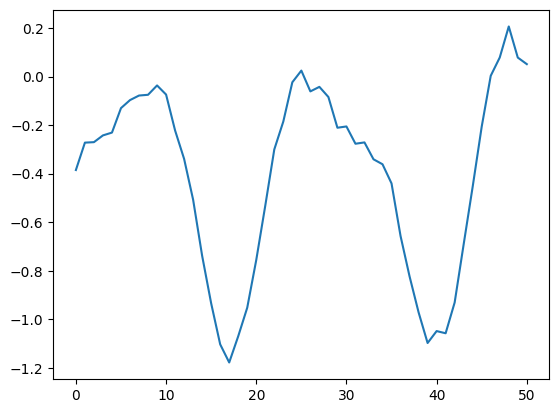

In [3]:
def generate_time_series(n_steps):
    freq1, freq2, offsets1, offsets2 = np.random.rand(4) 
    time = np.linspace(0, 1, n_steps)
    series = 0.5 * np.sin((time - offsets1) * (freq1 * 10 + 10)) # wave 1
    series += 0.2 * np.sin((time - offsets2) * (freq2 * 20 + 20)) # + wave 2
    series += 0.1 * np.random.rand(n_steps) - 0.5 # + noise
    return series[..., np.newaxis].astype(np.float32)

n_steps = 50
series = []
for i in range(10000):
    series.append(generate_time_series(n_steps + 1))
series = np.array(series)


print(series.shape)

plt.plot(series[700, :, 0])
plt.show()

In [4]:

X_train, y_train = series[:7000, :n_steps], series[:7000, -1]
X_valid, y_valid = series[7000:9000, :n_steps], series[7000:9000, -1]
X_test, y_test = series[9000:, :n_steps], series[9000:, -1]

In [5]:
print(X_valid.shape)
print(y_valid.shape)


(2000, 50, 1)
(2000, 1)


In [6]:
## create a baseline using a linear regression model (with keras)


import keras

model = keras.models.Sequential([
    keras.layers.Input(shape=[50, 1]),
    keras.layers.Flatten(),
    keras.layers.Dense(1)
])
model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,validation_data=(X_valid, y_valid))

y_pred_valid = model.predict(X_valid)

#compute the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_valid, y_pred_valid)
print("Mean Squared Error:", mse)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0881 - val_loss: 0.0387
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0269 - val_loss: 0.0211
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0185 - val_loss: 0.0164
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0153 - val_loss: 0.0138
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0132 - val_loss: 0.0119
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0115 - val_loss: 0.0104
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0100 - val_loss: 0.0091
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0088 - val_loss: 0.0080
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0078 - val_loss: 0.0078
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0070 - val_loss: 0.0063
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0063 - val_loss: 0.0057
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step

In [7]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 155 (624.00 B)

 Trainable params: 51 (204.00 B)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 104 (420.00 B)

### Create a simple RNN model

By default, the SimpleRNN layer uses the hyperbolic tangent activation function (-1, 1) range
We do not need to specify the length of the input sequences (unlike in the previous model), 
since a recurrent neural network can process any number of time steps 
(this is why we set the first input dimension to None).

This network has 3 parameters: the input weights, the recurrent weights, and the bias.


It works exactly as we saw earlier: the initial state h(init) is set to 0, and it is passed to a single recurrent neuron, along with the value of the first time step, x(0). The neuron computes a weighted sum of these values and applies the hyperbolic tangent activation function to the result, and this gives the first output, y0. In a simple RNN, this output is also the new state h0. This new state is passed to the same recurrent neuron along with the next input value, x(1), and the process is repeated until the last time step. Then the layer just outputs the last value, y49. All of this is performed simultaneously for every time series.

**By default, recurrent layers in Keras only return the final output.** This means that the the recurrent neuron cycles thought the input *without* emitting any outout. Only at the end, when the input is finished it outputs the final output. 
On the contrary, to make them return one output per time step, you shoud set *return_sequences=True*
Now it is a *sequence-to-vector* network

Since the output of a recurrent neuron at time step t is a function of all the inputs from previous time steps, you could say it has a form of memory. 
In general a cell’s **state** at time step t, denoted **h(t)** (the “h” stands for “hidden”), is a function of some inputs at that time step and its state at the previous time step: h(t) = f(h(t–1), x(t)). Its output at time step t, denoted y(t), is also a function of the previous state and the current inputs. 

In [11]:


model = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(1, return_sequences=False)
])



model.summary()
model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,validation_data=(X_valid, y_valid))

y_pred_valid = model.predict(X_valid)

#compute the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_valid, y_pred_valid)
print("Mean Squared Error:", mse)

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_1 (SimpleRNN)        │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3 (12.00 B)

 Trainable params: 3 (12.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1047 - val_loss: 0.0928
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0832 - val_loss: 0.0736
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0671 - val_loss: 0.0598
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0555 - val_loss: 0.0502
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0473 - val_loss: 0.0431
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0413 - val_loss: 0.0379
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0366 - val_loss: 0.0339
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0330 - val_loss: 0.0306
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0300 - val_loss: 0.0280
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0276 - val_loss: 0.0259
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0256 - val_loss: 0.0240
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

In [12]:
y_pred_valid.shape

(2000, 1)

In [13]:
y_valid.shape

(2000, 1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
(1000, 1)
(1000, 50, 1)


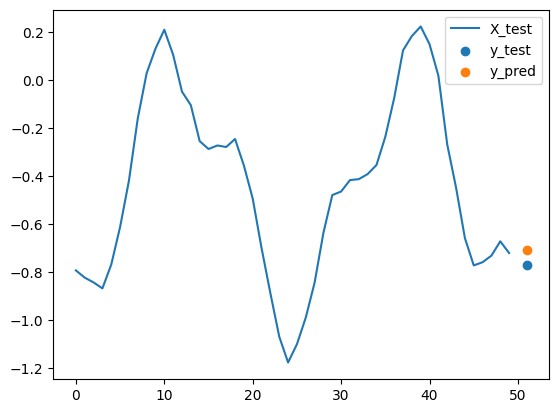

In [14]:
y_pred  = model.predict(X_test)
print(y_pred.shape)
print(X_test.shape)
plt.plot(X_test[100, :, 0], label='X_test')
plt.scatter(51,y_test[100,0], label='y_test')
plt.scatter(51,y_pred[100,0], label='y_pred')
plt.legend()
plt.show()

### Create a more complex RNN model with 2 layers and 20 neurons in each layer

<image src='figures/rnn2.png' width=500>

* The first layer: SimpleRNN(20,...) has 20 (X weights) + 20 (bias) + 20 * 20 (recurrent weights) = 440 params

* The second layer: SimpleRNN(20,...) has 20 * 20 (X weights) + 20 (bias) + 20 * 20 (recurrent weights) = 820 params

* Dense(1) layer has 20 + 1 parameters

Make sure to set return_sequences=True for all recurrent layers (except the last one, if you only care about the last output). If you don’t, they will output a 2D array (containing only the output of the last time step) instead of a 3D array (containing outputs for all time steps), and the next recurrent layer will complain that you are not feeding it sequences in the expected 3D format

In [15]:


model = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(1)
])

model.summary()
model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, y_train, epochs=20,validation_data=(X_valid, y_valid))

y_pred_valid = model.predict(X_valid)

#compute the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(y_valid, y_pred_valid)
print("Mean Squared Error:", mse)

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, None, 20)       │           440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 20)             │           820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            21 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,281 (5.00 KB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0141 - val_loss: 0.0050
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0043 - val_loss: 0.0038
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - val_loss: 0.0038
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0040 - val_loss: 0.0037
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0040 - val_loss: 0.0038
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0039 - val_loss: 0.0038
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0039 - val_loss: 0.0039
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039 - val_loss: 0.0040
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0039 - val_loss: 0.0036
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0037 - val_loss: 0.0035
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0036 - val_loss: 0.0033
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step

### Forecasting Several Time Steps Ahead

The first option is to use the model we already trained, make it predict the next value,
then add that value to the inputs (acting as if this predicted value had actually occurred),
and use the model again to predict the following value, and so on

In [19]:
series = generate_time_series(n_steps + 20)
series = np.array([series])
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]

print(X_new.shape)
print(Y_new.shape)

X_new = np.array([X_new[0]])
Y_new = np.array([Y_new[0]])

print(X_new.shape)
print(Y_new.shape)


X = X_new
for step_ahead in range(20):
    y_pred_one = model.predict(X)[:, np.newaxis, :]
    X = np.concatenate([X, y_pred_one], axis=1)

Y_pred = X[:, n_steps:] # at the end the predictions are in the last 10 steps of the X

(1, 50, 1)
(1, 20, 1)
(1, 50, 1)
(1, 20, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 318ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


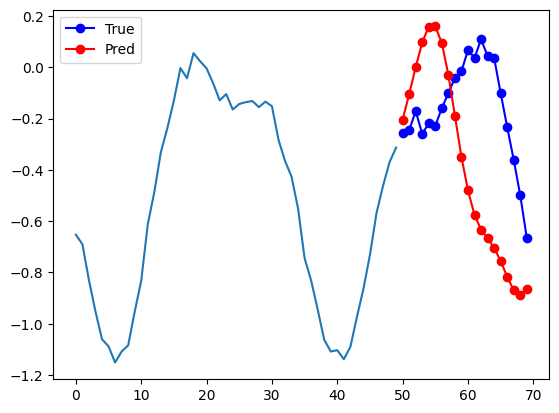

In [20]:
lx = X_new[0].shape[0]
plt.plot(range(lx), X_new[0])
plt.plot(range(lx, lx+Y_new[0].shape[0]), Y_new[0], "bo-", label="True")
plt.plot(range(lx, lx+Y_pred[0].shape[0]), Y_pred[0], "ro-", label="Pred")  
plt.legend()
plt.show()

The second option is to train an RNN to predict all 10 next values at once. We can
still use a sequence-to-vector model, but it will output 10 values instead of 1.

In [21]:

n_steps = 50
series = []
for i in range(10000):
    series.append(generate_time_series(n_steps + 10))
series = np.array(series)

X_train, Y_train = series[:7000, :n_steps], series[:7000, -10:, 0]
X_valid, Y_valid = series[7000:9000, :n_steps], series[7000:9000, -10:, 0]
X_test, Y_test = series[9000:, :n_steps], series[9000:, -10:, 0]


In [22]:
X_train.shape, Y_train.shape

((7000, 50, 1), (7000, 10))

In [23]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20),
    keras.layers.Dense(10)
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=20,validation_data=(X_valid, Y_valid))

Y_pred_valid = model.predict(X_valid)

#compute the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_valid, Y_pred_valid)
print("Mean Squared Error:", mse)

Epoch 1/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.1041 - val_loss: 0.0424
Epoch 2/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0368 - val_loss: 0.0304
Epoch 3/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0284 - val_loss: 0.0255
Epoch 4/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0239 - val_loss: 0.0200
Epoch 5/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0193 - val_loss: 0.0170
Epoch 6/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0172 - val_loss: 0.0153
Epoch 7/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0156 - val_loss: 0.0136
Epoch 8/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0142 - val_loss: 0.0139
Epoch 9/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0129 - val_loss: 0.0120
Epoch 10/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0126 - val_loss: 0.0114
Epoch 11/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0123 - val_loss: 0.0114
Epoch 12/20
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

(1, 50, 1)
(1, 10, 1)
(1, 50, 1)
(1, 10, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


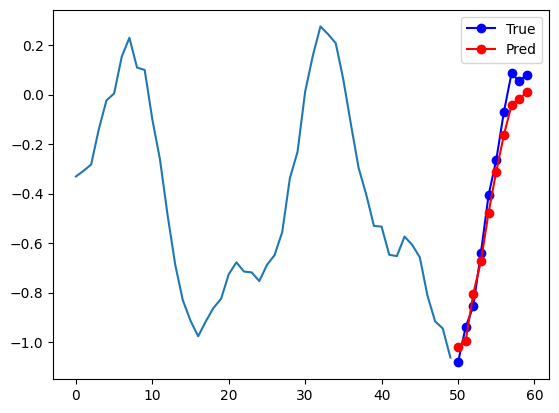

In [24]:
series = generate_time_series(n_steps + 10)
series = np.array([series])
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]

print(X_new.shape)
print(Y_new.shape)

X_new = np.array([X_new[0]])
Y_new = np.array([Y_new[0]])

print(X_new.shape)
print(Y_new.shape)

Y_pred = model.predict(X_new)

lx = X_new[0].shape[0]
plt.plot(range(lx), X_new[0])
plt.plot(range(lx, lx+Y_new[0].shape[0]), Y_new[0], "bo-", label="True")
plt.plot(range(lx, lx+Y_pred[0].shape[0]), Y_pred[0], "ro-", label="Pred")  
plt.legend()
plt.show()

In [25]:
X_train.shape, Y_train.shape

((7000, 50, 1), (7000, 10))

We can still do better: indeed, instead of training the model to forecast the next 10 values only at the very last time step, we can train it to forecast the next 10 values at each and every time step. In other words, we can turn this *sequence-to-vector* RNN into a *sequence-to-sequence* RNN. The advantage of this technique is that the loss will contain a term for the output of the RNN at each and every time step, not just the output at the last time step. This means there will be many more error gradients flowing through the model.

At time step 0 the model will output a vector containing the forecasts for
time steps 1 to 10, then at time step 1 the model will forecast time steps 2 to 11, and
so on. So each target must be a sequence of the same length as the input sequence,
containing a 10-dimensional vector at each step. 

**There must be many more Ys for the training.** Before we had X = time series of 50 steps, Y = time series of 10 steps, i.e., after seeing the whole X time series, the model outputs the Y time series.
Now, we shoud have Y = 50 time series of 10 steps each, in order ot provide a feedback to all the inputs.

Let’s prepare these target sequences:

In [34]:
n_steps = 5
series = []
for i in range(10000):
    series.append(generate_time_series(n_steps + 3))
series = np.array(series)
print(series.shape)

X_train = series[:7000, :n_steps]
X_valid = series[7000:9000, :n_steps]
X_test = series[9000:, :n_steps]
Y = np.empty((10000, n_steps, 3))

for step_ahead in range(1, 3 + 1):
    Y[..., step_ahead - 1] = series[..., step_ahead:step_ahead + n_steps, 0]

'''
Y[..., step_ahead - 1] = Y[10000, 50, step_ahead - 1] in our case
when step_ahead = 1 (it goes from 1 to 10)
Y[10000, 50, 0] = series[10000, 50, 1:11, 0] they ar the next 10 values of the series after the fist, i.e 0
Y[10000, 50, 1] = series[10000, 50, 2:12, 0] they ar the next 10 values of the series after the second, i.e 1
...
'''

print(Y.shape)

Y_train = Y[:7000]
Y_valid = Y[7000:9000]
Y_test = Y[9000:]

(10000, 8, 1)
(10000, 5, 3)


In [35]:
print(series.shape)
print(X_train.shape)
print(Y_train.shape)

(10000, 8, 1)
(7000, 5, 1)
(7000, 5, 3)


In [37]:
series[0,:,0]

array([-0.00625888,  0.05284256, -0.82457703, -0.9983157 , -0.20353289,
       -0.1784916 , -0.70473635, -0.49052736], dtype=float32)

In [39]:
X_train[0,:,0]

array([-0.00625888,  0.05284256, -0.82457703, -0.9983157 , -0.20353289],
      dtype=float32)

In [46]:
Y_train[0,4,:]

array([-0.17849161, -0.70473635, -0.49052736])

In [36]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.SimpleRNN(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(3))
])

model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=30,validation_data=(X_valid, Y_valid))

Epoch 1/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.1334 - val_loss: 0.1117
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1124 - val_loss: 0.1107
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1117 - val_loss: 0.1111
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1114 - val_loss: 0.1103
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1108 - val_loss: 0.1093
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1101 - val_loss: 0.1082
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1092 - val_loss: 0.1090
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1081 - val_loss: 0.1060
Epoch 9/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1069 - val_loss: 0.1052
Epoch 10/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1055 - val_loss: 0.1045
Epoch 11/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1047 - val_loss: 0.1035
Epoch 12/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

In [29]:
Y_pred_valid = model.predict(X_valid)

print(Y_pred_valid.shape)
print(Y_valid.shape)

#compute the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_valid[:,-1], Y_pred_valid[:,-1])
print("Mean Squared Error:", mse)



63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
(2000, 50, 10)
(2000, 50, 10)
Mean Squared Error: 0.012334690275597048


(1, 50, 1)
(1, 10, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Y_pred (1, 50, 10)
Y_pred (1, 10, 1)


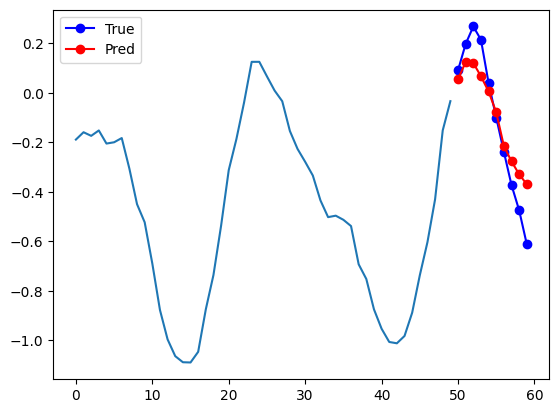

In [30]:
series = generate_time_series(n_steps + 10)
series = np.array([series])
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]

print(X_new.shape)
print(Y_new.shape)

#X_new = np.array((X_test[11],))
#Y_new = np.array((Y_test[11],))
#Y_new = Y_new[0][-1].reshape(1, 10, 1)
#print('X_new',X_new.shape)
#print('Y_new',Y_new.shape)


Y_pred = model.predict(X_new)

print('Y_pred',Y_pred.shape)

Y_pred = Y_pred[0][-1].reshape(1, 10, 1)

print('Y_pred',Y_pred.shape)

lx = X_new[0].shape[0]
plt.plot(range(lx), X_new[0])
plt.plot(range(lx, lx+Y_new[0].shape[0]), Y_new[0], "bo-", label="True")
plt.plot(range(lx, lx+Y_pred[0].shape[0]), Y_pred[0], "ro-", label="Pred")  
plt.legend()
plt.show()

You can combine this approach with the first one: just predict the next 10 values
using this RNN, then concatenate these values to the input time series and use the
model again to predict the next 10 values, and repeat the process as many times as
needed. With this approach, you can generate arbitrarily long sequences.

### Tackling the Short-Term Memory Problem

Due to the transformations that the data goes through when traversing an RNN, some information is lost at each time step. After a while, the RNN’s state contains virtually no trace of the first inputs. This can be a showstopper. Imagine Dory the fish trying to translate a long sentence; by the time she’s finished reading it, she has no clue how it started. To tackle this problem, various types of cells with long-term memory have been introduced. They have proven so successful that the basic cells are not used much anymore. Let’s first look at the most popular of these long-term memory cells: the LSTM (Long Short-Term Memory) cell.

In [24]:
model = keras.models.Sequential([
    keras.layers.Input(shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True, input_shape=[None, 1]),
    keras.layers.LSTM(20, return_sequences=True),
    keras.layers.TimeDistributed(keras.layers.Dense(10))
])
model.compile(loss="mse", optimizer="adam")
history = model.fit(X_train, Y_train, epochs=30,validation_data=(X_valid, Y_valid))

Epoch 1/30


c:\Users\marco\Dropbox\Documenti\DIDATTICA\ai-academy-kohler\venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


219/219 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.1928 - val_loss: 0.0677
Epoch 2/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0627 - val_loss: 0.0533
Epoch 3/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0513 - val_loss: 0.0462
Epoch 4/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0445 - val_loss: 0.0410
Epoch 5/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0401 - val_loss: 0.0375
Epoch 6/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0366 - val_loss: 0.0345
Epoch 7/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 14ms/step - loss: 0.0339 - val_loss: 0.0323
Epoch 8/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 30ms/step - loss: 0.0317 - val_loss: 0.0308
Epoch 9/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 33ms/step - loss: 0.0302 - val_loss: 0.0296
Epoch 10/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0295 - val_loss: 0.0287
Epoch 11/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0283 - val_loss: 0.0283
Epoch 12/30
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/ste

In [25]:
Y_pred_valid = model.predict(X_valid)

print(Y_pred_valid.shape)
print(Y_valid.shape)

#compute the mean squared error
from sklearn.metrics import mean_squared_error
mse = mean_squared_error(Y_valid[:,-1], Y_pred_valid[:,-1])
print("Mean Squared Error:", mse)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
(2000, 50, 10)
(2000, 50, 10)
Mean Squared Error: 0.008855730324995727


(1, 50, 1)
(1, 10, 1)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
Y_pred (1, 50, 10)
Y_pred (1, 10, 1)


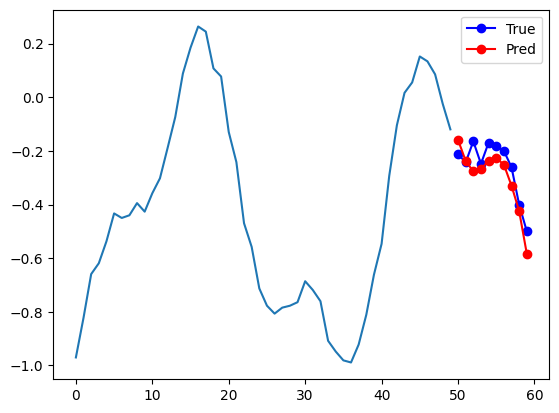

In [32]:
series = generate_time_series(n_steps + 10)
series = np.array([series])
X_new, Y_new = series[:, :n_steps], series[:, n_steps:]

print(X_new.shape)
print(Y_new.shape)

#X_new = np.array((X_test[11],))
#Y_new = np.array((Y_test[11],))
#Y_new = Y_new[0][-1].reshape(1, 10, 1)
#print('X_new',X_new.shape)
#print('Y_new',Y_new.shape)


Y_pred = model.predict(X_new)

print('Y_pred',Y_pred.shape)

Y_pred = Y_pred[0][-1].reshape(1, 10, 1)

print('Y_pred',Y_pred.shape)

lx = X_new[0].shape[0]
plt.plot(range(lx), X_new[0])
plt.plot(range(lx, lx+Y_new[0].shape[0]), Y_new[0], "bo-", label="True")
plt.plot(range(lx, lx+Y_pred[0].shape[0]), Y_pred[0], "ro-", label="Pred")  
plt.legend()
plt.show()